STEP 1: LOADING AMAZON STOCK DATA
✅ Loaded data for Amazon (AMZN)
📊 Data shape: (502, 7)

First 5 rows:
                                 Open        High         Low       Close  \
Date                                                                        
2024-02-28 00:00:00-05:00  172.440002  174.050003  172.270004  173.160004   
2024-02-29 00:00:00-05:00  173.009995  177.220001  172.850006  176.759995   
2024-03-01 00:00:00-05:00  176.750000  178.729996  176.070007  178.220001   
2024-03-04 00:00:00-05:00  177.529999  180.139999  177.490005  177.580002   
2024-03-05 00:00:00-05:00  176.929993  176.929993  173.300003  174.119995   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-02-28 00:00:00-05:00  28180500        0.0           0.0  
2024-02-29 00:00:00-05:00  53805400        0.0           0.0  
2024-03-01 00:00:00-05:00  31981200        0.0           0.0  
2024-03-04 00:00:00-05:00  37381500      

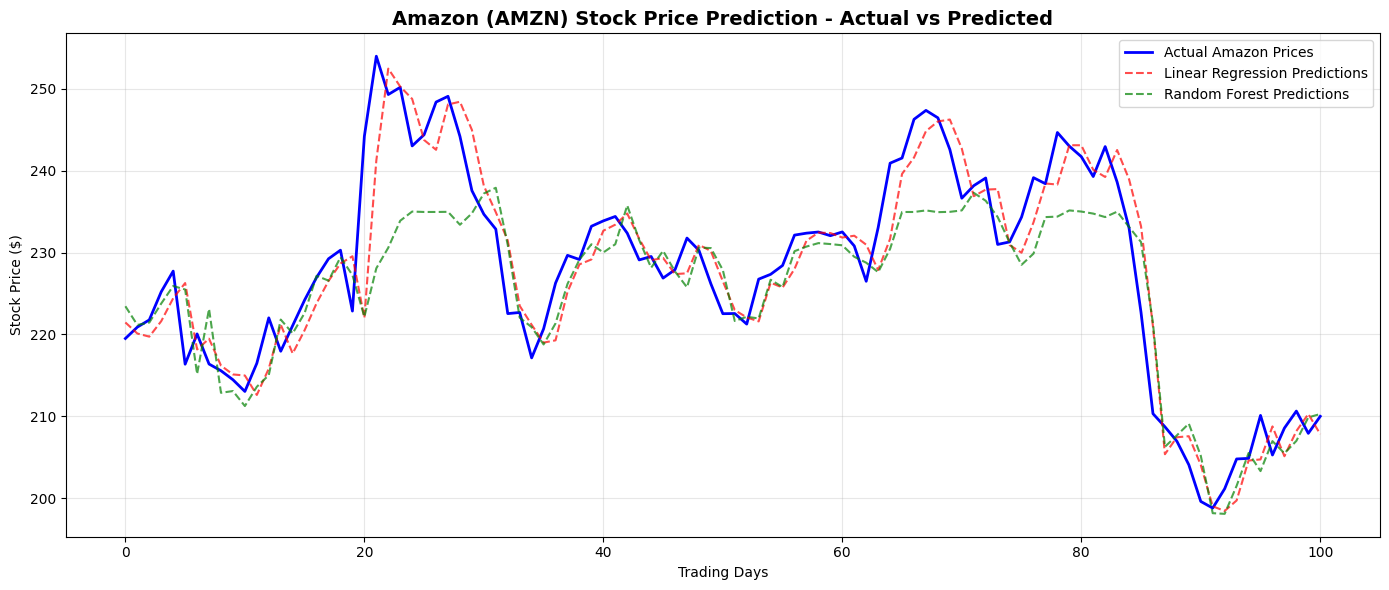


STEP 8: NEXT DAY PRICE PREDICTION

📈 Today's Close Price (Most Recent): $210.00

🔮 Predicted Tomorrow's Close Price:
   - Linear Regression: $207.81
   - Random Forest: $210.28
   - Average: $209.05


In [2]:
# Task 2: Predict Amazon Stock Prices (Short-Term)
# By : Saif Ullah
# AI/ML Engineering Internship - DevelopersHub Corporation

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD AMAZON STOCK DATA USING YFINANCE
# ============================================
print("="*60)
print("STEP 1: LOADING AMAZON STOCK DATA")
print("="*60)

# Amazon ticker symbol
ticker = 'AMZN'
stock = yf.Ticker(ticker)

# Load historical data (last 2 years)
data = stock.history(period='2y')
print(f"✅ Loaded data for Amazon ({ticker})")
print(f"📊 Data shape: {data.shape}")
print(f"\nFirst 5 rows:")
print(data.head())

# ============================================
# STEP 2: PREPARE FEATURES FOR PREDICTION
# ============================================
print("\n" + "="*60)
print("STEP 2: FEATURE ENGINEERING")
print("="*60)

# Use Open, High, Low, Volume to predict next Close price [citation:1]
df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Create target: Next day's closing price
df['Target'] = df['Close'].shift(-1)

# Remove rows with NaN values
df = df.dropna()

# Define features (X) and target (y)
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]
y = df['Target']

print(f"Features used: {features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# ============================================
# STEP 3: SPLIT DATA INTO TRAIN AND TEST SETS
# ============================================
print("\n" + "="*60)
print("STEP 3: TRAIN-TEST SPLIT")
print("="*60)

# Use last 20% of data for testing (preserve time order)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# ============================================
# STEP 4: TRAIN MODELS
# ============================================
print("\n" + "="*60)
print("STEP 4: TRAINING MODELS")
print("="*60)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("✅ Linear Regression trained")

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained")

# ============================================
# STEP 5: MAKE PREDICTIONS
# ============================================
print("\n" + "="*60)
print("STEP 5: MAKING PREDICTIONS")
print("="*60)

# Predict on test data
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("✅ Predictions completed")

# ============================================
# STEP 6: EVALUATE MODELS
# ============================================
print("\n" + "="*60)
print("STEP 6: MODEL EVALUATION")
print("="*60)

# Calculate metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = lr_model.score(X_test, y_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = rf_model.score(X_test, y_test)

print("\n📊 Linear Regression Performance:")
print(f"   MAE:  ${lr_mae:.2f}")
print(f"   RMSE: ${lr_rmse:.2f}")
print(f"   R²:   {lr_r2:.4f}")

print("\n📊 Random Forest Performance:")
print(f"   MAE:  ${rf_mae:.2f}")
print(f"   RMSE: ${rf_rmse:.2f}")
print(f"   R²:   {rf_r2:.4f}")

# ============================================
# STEP 7: PLOT ACTUAL VS PREDICTED PRICES
# ============================================
print("\n" + "="*60)
print("STEP 7: VISUALIZING RESULTS")
print("="*60)

plt.figure(figsize=(14, 6))

# Plot actual vs predicted
plt.plot(y_test.values, label='Actual Amazon Prices', color='blue', linewidth=2)
plt.plot(lr_pred, label='Linear Regression Predictions', color='red', linestyle='--', alpha=0.7)
plt.plot(rf_pred, label='Random Forest Predictions', color='green', linestyle='--', alpha=0.7)

plt.title('Amazon (AMZN) Stock Price Prediction - Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('amazon_stock_prediction.png', dpi=100)
plt.show()

# ============================================
# STEP 8: PREDICT NEXT DAY'S PRICE
# ============================================
print("\n" + "="*60)
print("STEP 8: NEXT DAY PRICE PREDICTION")
print("="*60)

# Get the most recent data
latest_data = X.iloc[-1:].values

# Predict tomorrow's price using both models
tomorrow_lr = lr_model.predict(latest_data)[0]
tomorrow_rf = rf_model.predict(latest_data)[0]

today_close = data['Close'].iloc[-1]

print(f"\n📈 Today's Close Price (Most Recent): ${today_close:.2f}")
print(f"\n🔮 Predicted Tomorrow's Close Price:")
print(f"   - Linear Regression: ${tomorrow_lr:.2f}")
print(f"   - Random Forest: ${tomorrow_rf:.2f}")
print(f"   - Average: ${(tomorrow_lr + tomorrow_rf)/2:.2f}")
